In [14]:
# Load dataframe

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('male-elephant-tusk-size.csv')
df

,period,elephant_id,age,shoulder_height,tusk_length
0,1966-68,58,2.5,149.0,30.0
1,1966-68,78,2.5,151.0,27.0
2,1966-68,86,2.5,127.0,27.0
3,1966-68,293,2.5,156.0,32.0
4,1966-68,29,3.0,146.0,28.5
...,...,...,...,...,...
294,2005-13,78,7.5,220.0,84.7
295,2005-13,144,7.5,220.0,58.9
296,2005-13,1,9.0,220.0,99.0
297,2005-13,48,9.0,230.0,105.4


In [15]:
# Comparing tusk length - selecting top 3 for a certain period

pre_poaching = df.query('period == "1966-68"')
pre_poaching.head(3)

,period,elephant_id,age,shoulder_height,tusk_length
0,1966-68,58,2.5,149.0,30.0
1,1966-68,78,2.5,151.0,27.0
2,1966-68,86,2.5,127.0,27.0


In [16]:
# Comparing tusk length - selecting top 3 for a certain period

post_recovery = df.query('period == "2005-13"')
post_recovery.head(3)

,period,elephant_id,age,shoulder_height,tusk_length
214,2005-13,52,4.5,195.0,47.0770
215,2005-13,14,5.0,200.0,48.2328
216,2005-13,42,5.0,180.0,54.0118


In [17]:
# Comparing tusk length for selected period above

print('Before:', pre_poaching['tusk_length'].mean())
print('After:', post_recovery['tusk_length'].mean())

Before: 67.44088785046729
After: 57.968809411764695


Text(220, 35, 'Post-recovery')

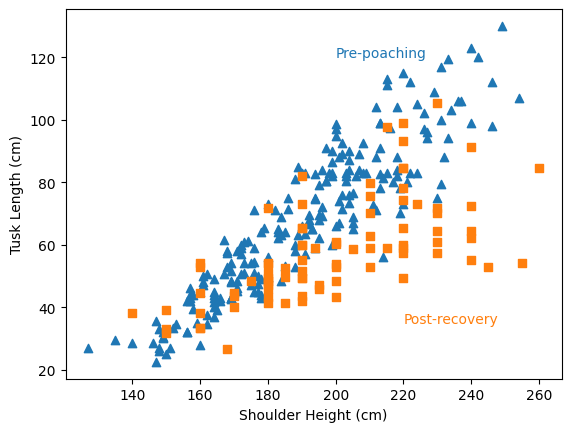

In [18]:
# Plot tusk length vs shoulder height

plt.scatter(pre_poaching['shoulder_height'], pre_poaching['tusk_length'], marker='^')
plt.scatter(post_recovery['shoulder_height'], post_recovery['tusk_length'], marker='s')

# Label axes

plt.xlabel('Shoulder Height (cm)')
plt.ylabel('Tusk Length (cm)')

# Labeling the two groups directly on the plot

plt.text(x=200, y=120, s='Pre-poaching', color='C0')
plt.text(x=220, y=35, s='Post-recovery', color='C1')

In [19]:
# MODELING TUSK LENGTH USING SCIKIT-LEARN TO CREATE A PYTHON CLASS

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

class LinearModel:
    def __init__(self, model_name=""):
        self.model_name = model_name
        
    def fit(self, x, y):
        x = pd.DataFrame(x)
        linear_model = LinearRegression().fit(x, y)
        y_pred = linear_model.predict(x)
        self.slope = linear_model.coef_[0]
        self.intercept = linear_model.intercept_
        self.rsquared = r2_score(y, y_pred)
        
    def predict(self, x):
        return self.slope * x + self.intercept

    def plot_model(self, x_min, x_max, color="black"):
        y_min = self.predict(x_min)
        y_max = self.predict(x_max)
        plt.plot([x_min, x_max], [y_min, y_max], color=color)
        
    def print_model_info(self):
        m = self.slope
        b = self.intercept
        rsquared = self.rsquared
        model_name = self.model_name
        print(f'LinearModel({model_name}):')
        print(f'Parameters: slope = {m:.2f}, intercept = {b:.2f}')
        print(f'Equation: y = {m:.2f}x + {b:.2f}')
        print(f'Goodness of Fit (R²): {rsquared:.3f}')

In [20]:
# Create a linear model object for the pre-poaching data

pre_model = LinearModel("pre_poaching")
pre_model.fit(x=pre_poaching['shoulder_height'], y=pre_poaching['tusk_length'])

In [21]:
# Create a linear model object for the post-recovery data

post_model = LinearModel("post_recovery")
post_model.fit(x=post_recovery['shoulder_height'], y=post_recovery['tusk_length'])

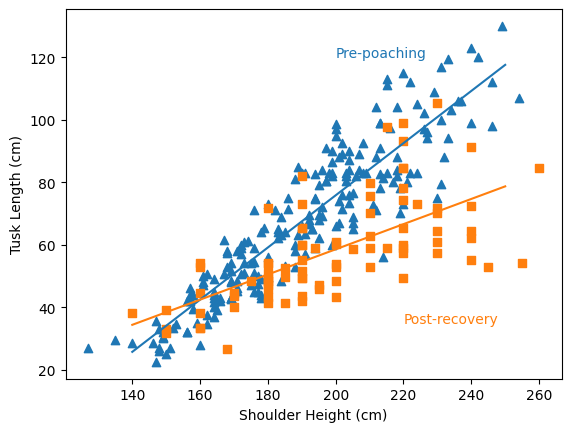

In [22]:
# Plotting the models

plt.scatter(pre_poaching['shoulder_height'], pre_poaching['tusk_length'], marker='^')
plt.scatter(post_recovery['shoulder_height'], post_recovery['tusk_length'], marker='s')

# Label axes

plt.xlabel('Shoulder Height (cm)')
plt.ylabel('Tusk Length (cm)')

# Labeling the two groups directly on the plot

plt.text(200, 120, 'Pre-poaching', color='C0')
plt.text(220, 35, 'Post-recovery', color='C1')

# Model plot

pre_model.plot_model(140, 250, 'C0')
post_model.plot_model(140, 250, 'C1')

In [ ]:
# Print model info for precise info - Pre-poaching

pre_model.print_model_info()

LinearModel(pre_poaching):
Parameters: slope = 0.83, intercept = -91.14
Equation: y = 0.83x + -91.14
Goodness of Fit (R²): 0.831


In [ ]:
# Print model info for precise info - Post-recovery

post_model.print_model_info()

LinearModel(post_recovery):
Parameters: slope = 0.40, intercept = -22.02
Equation: y = 0.40x + -22.02
Goodness of Fit (R²): 0.431
